# Import Libraries

In [51]:
import io 
import itertools 
import numpy as np 
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorboard.plugins.hparams import api as hp 
import matplotlib.pyplot as plt

# Loading Dataset

In [6]:
data_train = np.load(r"Dataset/Primary categories - Train.npz")
data_val = np.load(r"Dataset/Primary categories - Validation.npz")
data_test = np.load(r"Dataset/Primary categories - Test.npz")

In [8]:
images_train = data_train['images']
labels_train = data_train['labels']

images_val = data_val['images']
labels_val = data_val['labels']

images_test = data_test['images']
labels_test = data_test['labels']

In [9]:
images_train = images_train/255.0
images_val = images_val/255.0
images_test = images_test/255.0

# Hyperparameter Tuning

In [12]:
EPOCHS = 15 
BATCH_SIZE = 64 

In [13]:
HP_FILTER_SIZE = hp.HParam('filter_size', hp.Discrete([3, 5, 7]))
HP_FILTER_NUM = hp.HParam('filter_number', hp.Discrete([32, 64, 96, 128]))

METRIC_ACCURACY = 'accuracy'

with tf.summary.create_file_writer("Logs/Model 1/hparam/tuning").as_default():
    hp.hparams_config(
        hparams=[HP_FILTER_SIZE, HP_FILTER_NUM],
        metrics=[hp.Metric(METRIC_ACCURACY, display_name='Accuracy')],
    )

In [32]:
def train_test_model(hparams, session_num):
    
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(hparams[HP_FILTER_NUM], hparams[HP_FILTER_SIZE], activation='relu', input_shape=(120,90,3)),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
        tf.keras.layers.Conv2D(hparams[HP_FILTER_NUM], 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(3)
    ])
    
    # loss function
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    # compile the model
    model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])

    # logging directory
    log_dir = "Logs/Model 1/fit/" + "run-{}".format(session_num)
    

    def plot_confusion_matrix(cm, class_names):
        """
        Returns a matplotlib figure containing the plotted confusion matrix.

        Args:
          cm (array, shape = [n, n]): a confusion matrix of integer classes
          class_names (array, shape = [n]): String names of the integer classes
        """
        figure = plt.figure(figsize=(12, 12))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title("Confusion matrix")
        plt.colorbar()
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=45)
        plt.yticks(tick_marks, class_names)

        # normalize the confusion matrix
        cm = np.around(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], decimals=2)

        # use white text if squares are dark; otherwise black
        threshold = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            color = "white" if cm[i, j] > threshold else "black"
            plt.text(j, i, cm[i, j], horizontalalignment="center", color=color)

        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        return figure
    
    
    def plot_to_image(figure):
        """Converts the matplotlib plot specified by 'figure' to a PNG image and
        returns it. The supplied figure is closed and inaccessible after this call."""
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        plt.close(figure)
        buf.seek(0)
        image = tf.image.decode_png(buf.getvalue(), channels=4)
        image = tf.expand_dims(image, 0)
        return image
    
    # defining a file writer for confusion matrix logging purposes
    file_writer_cm = tf.summary.create_file_writer(log_dir + '/cm')     
    
    def log_confusion_matrix(epoch, logs):
        # use the model to predict the values from the validation dataset
        test_pred_raw = model.predict(images_val)
        test_pred = np.argmax(test_pred_raw, axis=1)

        # calculate the confusion matrix
        cm = sklearn.metrics.confusion_matrix(labels_val, test_pred)
        figure = plot_confusion_matrix(cm, class_names=['Glasses/Sunglasses', 'Trousers/Jeans', 'Shoes'])
        cm_image = plot_to_image(figure)

        # log the confusion matrix as an image summary
        with file_writer_cm.as_default():
            tf.summary.image("Confusion Matrix", cm_image, step=epoch)

    cm_callback = tf.keras.callbacks.LambdaCallback(on_epoch_end=log_confusion_matrix)
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, profile_batch=0)


    # early stopping to prevent overfitting
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        mode = 'auto',
        min_delta = 0,
        patience = 2,
        verbose = 0, 
        restore_best_weights = True
    )
    
    # training the model
    model.fit(
        images_train,
        labels_train,
        epochs = EPOCHS,
        batch_size = BATCH_SIZE,
        callbacks = [tensorboard_callback, cm_callback, early_stopping],
        validation_data = (images_val,labels_val),
        verbose = 2
    )
    
    # evaluating the model's performance on the validation set
    _, accuracy = model.evaluate(images_val,labels_val)
    
    # saving the current model for future reference
    model.save(r"saved_models/Model 1/Run-{}.keras".format(session_num))
    
    return accuracy

In [33]:
def run(log_dir, hparams, session_num):
    
    with tf.summary.create_file_writer(log_dir).as_default():
        hp.hparams(hparams)  
        accuracy = train_test_model(hparams, session_num)
        tf.summary.scalar(METRIC_ACCURACY, accuracy, step=1)

In [35]:
session_num = 1

for filter_size in HP_FILTER_SIZE.domain.values:
    for filter_num in HP_FILTER_NUM.domain.values:

        hparams = {
            HP_FILTER_SIZE: filter_size,
            HP_FILTER_NUM: filter_num
        }

        run_name = "run-%d" % session_num
        print('Starting trial: %s' % run_name)
        print({h.name: hparams[h] for h in hparams})
        run('Logs/Model 1/hparam_tuning/' + run_name, hparams, session_num)

        session_num += 1

Starting trial: run-1
{'filter_size': 3, 'filter_number': 32}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
203/203 - 17s - 83ms/step - accuracy: 0.9723 - loss: 0.1036 - val_accuracy: 0.9988 - val_loss: 0.0065
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
203/203 - 18s - 86ms/step - accuracy: 0.9986 - loss: 0.0114 - val_accuracy: 0.9988 - val_loss: 0.0041
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
203/203 - 18s - 90ms/step - accuracy: 0.9992 - loss: 0.0083 - val_accuracy: 0.9988 - val_loss: 0.0042
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
203/203 - 18s - 90ms/step - accuracy: 0.9989 - loss: 0.0082 - val_accuracy: 0.9975 - val_loss: 0.0114
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9988 - loss: 0.0041
Starting trial: run-2
{'filter_size': 3, 'filter_number': 64}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
203/203 - 44s - 217ms/step - accuracy: 0.9700 - loss: 0.1307 - val_accuracy: 0.9994 - val_loss: 0.0040
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
203/203 - 44s - 218ms/step - accuracy: 0.9981 - loss: 0.0146 - val_accuracy: 0.9988 - val_loss: 0.0063
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
203/203 - 45s - 221ms/step - accuracy: 0.9986 - loss: 0.0102 - val_accuracy: 0.8741 - val_loss: 0.3974
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9994 - loss: 0.0040
Starting trial: run-3
{'filter_size': 3, 'filter_number': 96}


...

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
203/203 - 621s - 3s/step - accuracy: 0.9748 - loss: 0.0838 - val_accuracy: 0.9994 - val_loss: 0.0054
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
203/203 - 1072s - 5s/step - accuracy: 0.9970 - loss: 0.0176 - val_accuracy: 0.9981 - val_loss: 0.0104
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
203/203 - 1073s - 5s/step - accuracy: 0.9984 - loss: 0.0112 - val_accuracy: 0.9988 - val_loss: 0.0039
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 540ms/step
203/203 - 675s - 3s/step - accuracy: 0.9990 - loss: 0.0075 - val_accuracy: 0.9981 - val_loss: 0.0057
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
203/203 - 498s - 2s/step - accuracy: 0.9986 - loss: 0.0065 - val_accuracy: 0.9981 - val_loss: 0.0056
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9988 - loss: 0.0039
Starting trial: run-11
{'filter_size': 7, 'filter_number': 96}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 566ms/step
203/203 - 1674s - 8s/step - accuracy: 0.9706 - loss: 0.0902 - val_accuracy: 0.9975 - val_loss: 0.0113
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step
203/203 - 1657s - 8s/step - accuracy: 0.9971 - loss: 0.0176 - val_accuracy: 0.9969 - val_loss: 0.0088
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step
203/203 - 1981s - 10s/step - accuracy: 0.9984 - loss: 0.0150 - val_accuracy: 0.9988 - val_loss: 0.0047
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
203/203 - 1649s - 8s/step - accuracy: 0.9992 - loss: 0.0077 - val_accuracy: 0.9988 - val_loss: 0.0042
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 563ms/step
203/203 - 2028s - 10s/step - accuracy: 0.9984 - loss: 0.0087 - val_accuracy: 0.9963 - val_loss: 0.0223
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step
203/203 - 1173s - 6s/step - accuracy: 0.9789 - loss: 0.0739 - val_accuracy: 0.9975 - val_loss: 0.0093
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 564ms/step - accuracy: 0.9988 - loss: 0.0042


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step
203/203 - 1886s - 9s/step - accuracy: 0.9741 - loss: 0.1057 - val_accuracy: 0.9975 - val_loss: 0.0076
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step
203/203 - 2749s - 14s/step - accuracy: 0.9921 - loss: 0.0320 - val_accuracy: 0.9969 - val_loss: 0.0144
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 30s 589ms/step
203/203 - 2586s - 13s/step - accuracy: 0.9975 - loss: 0.0172 - val_accuracy: 0.9802 - val_loss: 0.0549
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.9975 - loss: 0.0076


In [41]:
%load_ext tensorboard
%tensorboard --logdir "Logs/Model 1/hparam_tuning"

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 10586), started 0:28:34 ago. (Use '!kill 10586' to kill it.)

In [78]:
model = tf.keras.models.load_model("saved_models/Model 1/Run-4.keras")

# Predictions on Data Test

In [79]:
pred_probs = model.predict(images_test)
pred_classes = np.argmax(pred_probs, axis=1)
acc = accuracy_score(labels_test, pred_classes)
print('Test data accuracy: ', acc * 100, '%')

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step
Test data accuracy:  99.81481481481481 %


In [80]:
print(classification_report(labels_test, pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       518
           1       1.00      1.00      1.00       470
           2       1.00      1.00      1.00       632

    accuracy                           1.00      1620
   macro avg       1.00      1.00      1.00      1620
weighted avg       1.00      1.00      1.00      1620



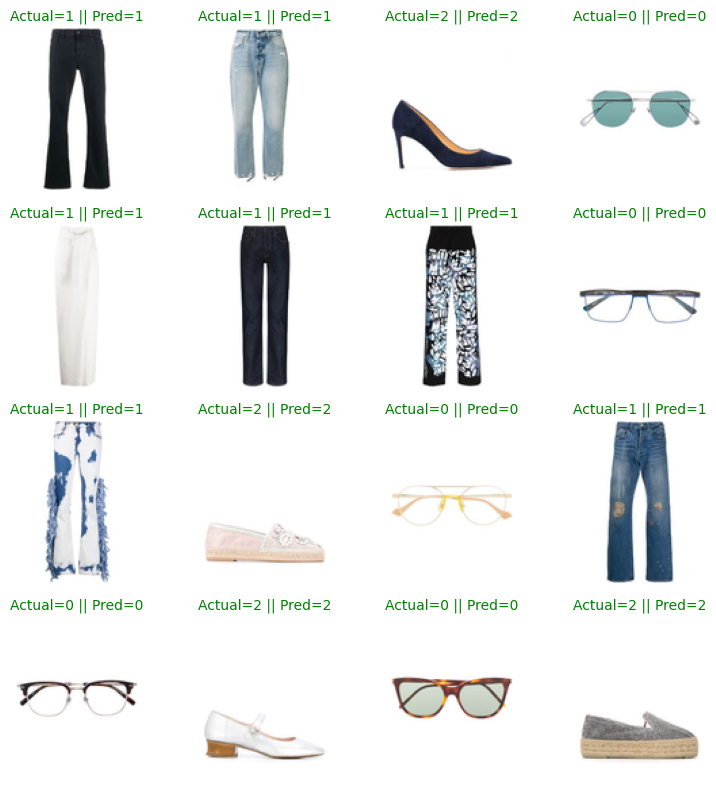

In [77]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.ravel() 
random_indices = np.random.choice(len(images_test), 16, replace=False)
for i, idx in enumerate(random_indices):
    img = images_test[idx]
    actual_label = labels_test[idx]
    predicted_label = pred_classes[idx]
    axes[i].imshow(img)
    axes[i].axis('off') 
    text_color = 'green' if actual_label == predicted_label else 'red'
    axes[i].set_title(f"Actual={actual_label} || Pred={predicted_label}", 
                      color=text_color, fontsize=10)
plt.tight_layout()
plt.show()